<a href="https://colab.research.google.com/github/aadityambk-del/bootcamp26/blob/main/miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df=pd.read_csv('AB_NYC_2019.csv.zip')
df.shape

(48895, 16)

In [90]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [91]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [92]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


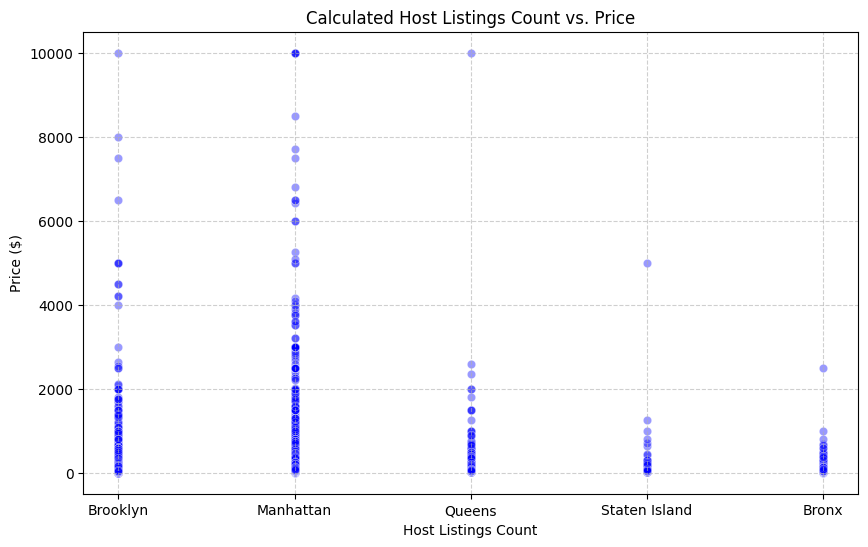

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['neighbourhood_group'],
    y=df['price'],
    alpha=0.4,
    color='blue'
)

plt.title("Calculated Host Listings Count vs. Price")
plt.xlabel("Host Listings Count")
plt.ylabel("Price ($)")
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [94]:
df = df.drop(['id', 'name', 'host_id', 'host_name', 'last_review'], axis=1)

In [95]:
df.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,10052
calculated_host_listings_count,0


In [96]:
df = df.dropna()

In [97]:
print(df.isnull().sum())
df.head()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
5,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,0.59,1,129


In [98]:
import numpy as np

df = df[(df['price'] >= 10) & (df['price'] <= 200)].copy()
df['dist_to_center'] = np.sqrt((df['latitude'] - 40.7580)**2 + (df['longitude'] - -73.9855)**2)
df = df.drop(['neighbourhood', 'latitude', 'longitude'], axis=1, errors='ignore')

print("Feature Engineering done")

Feature Engineering done


In [99]:
df.describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,dist_to_center
count,32941.000000,32941.000000,32941.000000,32941.000000,32941.000000,32941.000000,32941.000000
mean,101.541210,5.869403,30.305698,1.385000,3.450138,109.157433,0.076419
std,46.933199,17.860937,49.569286,1.712651,13.203520,127.879323,0.045704
min,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000717
25%,63.000000,1.000000,3.000000,0.190000,1.000000,0.000000,0.044604
50%,95.000000,2.000000,10.000000,0.710000,1.000000,45.000000,0.072751
75%,135.000000,4.000000,35.000000,2.040000,2.000000,212.000000,0.096840
max,200.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,0.358924


In [100]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

categorical_cols = ['neighbourhood_group', 'room_type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


X = df.drop(['price'], axis=1, errors='ignore')
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [101]:
df

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,dist_to_center,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,149,1,9,0.21,6,365,0.111287,True,False,False,False,True,False
3,89,1,270,4.64,1,194,0.077273,True,False,False,False,False,False
4,80,10,9,0.10,1,0,0.058001,False,True,False,False,False,False
5,200,3,74,0.59,1,129,0.014730,False,True,False,False,False,False
6,60,45,49,0.40,1,0,0.077011,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48732,150,4,1,1.00,1,13,0.040026,False,True,False,False,False,False
48782,129,1,1,1.00,1,147,0.039272,False,True,False,False,True,False
48790,45,1,1,1.00,6,339,0.171052,False,False,True,False,True,False
48805,100,1,2,2.00,1,40,0.079179,False,False,False,False,False,False


In [102]:

gb_clean = GradientBoostingRegressor(n_estimators=50, random_state=42)
gb_clean.fit(X_train, y_train)
clean_pred = gb_clean.predict(X_test)

print("Clean Data Gradient Boosting Metrics:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, clean_pred)))
print("R2 Score:", r2_score(y_test, clean_pred))

Clean Data Gradient Boosting Metrics:
RMSE: 31.07923369657201
R2 Score: 0.5623256436688557


In [103]:
df.describe()



,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,dist_to_center
count,32941.000000,32941.000000,32941.000000,32941.000000,32941.000000,32941.000000,32941.000000
mean,101.541210,5.869403,30.305698,1.385000,3.450138,109.157433,0.076419
std,46.933199,17.860937,49.569286,1.712651,13.203520,127.879323,0.045704
min,10.000000,1.000000,1.000000,0.010000,1.000000,0.000000,0.000717
25%,63.000000,1.000000,3.000000,0.190000,1.000000,0.000000,0.044604
50%,95.000000,2.000000,10.000000,0.710000,1.000000,45.000000,0.072751
75%,135.000000,4.000000,35.000000,2.040000,2.000000,212.000000,0.096840
max,200.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,0.358924


In [104]:
from sklearn.preprocessing import StandardScaler


cols_to_scale = [ 'minimum_nights',
    'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365',
]
scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Numerical features scaled")

Numerical features successfully scaled!


In [105]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
print("Linear Regression Metrics:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2 Score:", r2_score(y_test, lr_pred))

Linear Regression Metrics:
RMSE: 32.59120343400679
R2 Score: 0.5187050644839847


In [106]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest Metrics:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))



Random Forest Metrics:
RMSE: 31.189946811537546
R2 Score: 0.5592018472854072


In [107]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
print("Gradient Boosting Metrics:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R2 Score:", r2_score(y_test, gb_pred))

Gradient Boosting Metrics:
RMSE: 30.775017949084955
R2 Score: 0.5708519659765868


In [108]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

llr = Lasso()
llr.fit(X_train, y_train)

llr_pred = llr.predict(X_test)
print("Lasso Metrics:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, llr_pred)))
print("R2 Score:", r2_score(y_test, llr_pred))

Lasso Metrics:
RMSE: 34.97459114206027
R2 Score: 0.4457371252292225


In [109]:
rlr = Ridge()
rlr.fit(X_train, y_train)

rlr_pred = rlr.predict(X_test)
print("Ridge Metrics:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rlr_pred)))
print("R2 Score:", r2_score(y_test, rlr_pred))


Ridge Metrics:
RMSE: 32.595905465815136
R2 Score: 0.5185661787045666


In [110]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}
gb = GradientBoostingRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42,
    verbose=2
)


print("Starting Hyperparameter Tuning... grab a coffee! ☕")
random_search.fit(X_train, y_train)

best_gb = random_search.best_estimator_
best_pred = best_gb.predict(X_test)

print(f"\nBest Hyperparameters Found: {random_search.best_params_}")
print("Tuned Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, best_pred)))
print("Tuned Gradient Boosting R2 Score:", r2_score(y_test, best_pred))

Starting Hyperparameter Tuning... grab a coffee! ☕
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Hyperparameters Found: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': 7, 'learning_rate': 0.05}
Tuned Gradient Boosting RMSE: 30.46693792254556
Tuned Gradient Boosting R2 Score: 0.5794011190406532


In [111]:
import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("\nXGBoost Metrics:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2 Score:", r2_score(y_test, xgb_pred))

Training XGBoost...

XGBoost Metrics:
RMSE: 30.424799029674688
R2 Score: 0.5805637836456299


In [112]:
from sklearn.metrics import r2_score

r2_lr = r2_score(y_test, lr_pred)
r2_rf = r2_score(y_test, rf_pred)
r2_gb = r2_score(y_test, gb_pred)
r2_lasso = r2_score(y_test, llr_pred)
r2_ridge = r2_score(y_test, rlr_pred)
r2_tuned_gb = r2_score(y_test, best_pred)
r2_xgb = r2_score(y_test, xgb_pred)


best_score = max(r2_lr, r2_rf, r2_gb, r2_lasso, r2_ridge, r2_tuned_gb, r2_xgb)

print("The best model is...\n")

if best_score == r2_xgb:
    print(f"XGBoost! (Score: {best_score})")
elif best_score == r2_tuned_gb:
    print(f"Tuned Gradient Boosting! (Score: {best_score})")
elif best_score == r2_gb:
    print(f"Base Gradient Boosting! (Score: {best_score})")
elif best_score == r2_rf:
    print(f"Random Forest! (Score: {best_score})")
elif best_score == r2_ridge:
    print(f"Ridge Regression! (Score: {best_score})")
elif best_score == r2_lr:
    print(f"Linear Regression! (Score: {best_score})")
else:
    print(f"Lasso Regression! (Score: {best_score})")

The best model is...

XGBoost! (Score: 0.5805637836456299)
